In [1]:
import numpy as np
np.set_printoptions(precision=5)
import matplotlib.pyplot as plt

# Class implementation of detector setup

In [2]:
class DetectorSetup:
    def __init__(self, average_layer_radii: list, layerthickness: list, detector_resolutions_rphi: list, detector_resolutions_z: list, radiation_length_medium: float, magnetic_field_strength: float):
        self.average_layer_radii_setup = np.array(average_layer_radii)
        self.layerthickness_setup = np.array(layerthickness)
        self.detector_resolutions_rphi_setup = np.array(detector_resolutions_rphi)
        self.detector_resolutions_z_setup = np.array(detector_resolutions_z)
        self.radiation_length_medium = radiation_length_medium
        self.magnetic_field_strength = magnetic_field_strength
        self.number_of_layers = len(average_layer_radii)
        self.MS_in_air = True

        if self.radiation_length_medium <= 0:
            raise ValueError("The radiation length of the medium must be positive")
        
        if self.magnetic_field_strength <= 0:
            raise ValueError("The magnetic field strength must be positive")
        
        if self.number_of_layers <= 1:
            raise ValueError("The number of layers must be greater than 1")

        if len(average_layer_radii) == len(layerthickness) == len(detector_resolutions_rphi) == len(detector_resolutions_z):
            print("Detector Setup initialized")
        else:
            raise ValueError("The lists do not have the same length")
        
        def _g0(x):               #  trackmodel helper functions 
            return x**0     
        def _g1(x):
            return x**1
        def _g2(x):
            return x**2 /2
        
        self.g0 = _g0
        self.g1 = _g1
        self.g2 = _g2
        
##########################################################################
#############            Helper Functions            #####################
##########################################################################
        
    def _get_layers_with_hits(self, N: int):                                                    #helper function to get ITS2 layers starting from IU layer
        if N > self.number_of_layers:
            raise ValueError("The number of layers with hits cannot exceed the total number of layers")
        if N < 0:
            raise ValueError("The number of layers with hits cannot be negative")
        assert N == int(N), "The number of layers with hits must be an integer"
        
        self.IU_layer = self.number_of_layers - N
        self.average_layer_radii = self.average_layer_radii_setup[self.IU_layer:] - self.average_layer_radii_setup[self.IU_layer]
        self.layerthickness = self.layerthickness_setup[self.IU_layer:]
        self.detector_resolutions_rphi = self.detector_resolutions_rphi_setup[self.IU_layer:]
        self.detector_resolutions_z = self.detector_resolutions_z_setup[self.IU_layer:]


    def _get_circ_arc_length(self, momentum: float, chord_length):                                                  # calculates the length of a circular arc with given particle momentum and chord length
        radius_of_curvature = 1/(0.3*self.magnetic_field_strength) * momentum                              # radius of the curvature of the particle trajectory in meters
        try:
            if chord_length.all() > 2*radius_of_curvature:
                raise ValueError("The distances between detector layers cannot exceed 2*radius of curvature of the particle track inside the magnetic field")
        except:
            if chord_length > 2*radius_of_curvature:
                raise ValueError("The extrapolation radius cannot exceed 2*radius of curvature of the particle track inside the magnetic field")
        return 2 * radius_of_curvature * np.arcsin(chord_length / (2 * radius_of_curvature))                # length of the circular arc
    
        
    def _get_air_thickness_straight(self):               # helper function to calculate the amount of air in between the ITS layers in units of radiation length
        distances_between_layers = []
        distances_between_layers.append(10**(-90))                                          # to create extra entry
        for i in range(len(self.average_layer_radii)-1):
            distances_between_layers.append(self.average_layer_radii[i+1] - self.average_layer_radii[i])
        air_thickness = np.array(distances_between_layers) / self.radiation_length_medium
        return air_thickness
    
    def _get_air_thickness_parabolic(self, momentum: float):        # helper function to calculate the amount of air in between the ITS layers in units of radiation length
        distances_between_layers = []
        distances_between_layers.append(10**(-90))                                          # to create extra entry
        for i in range(len(self.average_layer_radii)-1):
            distances_between_layers.append(self.average_layer_radii[i+1] - self.average_layer_radii[i])
        distances_between_layers_corr = self._get_circ_arc_length(momentum, np.array(distances_between_layers))
        air_thickness = np.array(distances_between_layers_corr) / self.radiation_length_medium
        return air_thickness


    def _get_rms_ScatteringAngle(self, momentum: float, mass: float, material_thickness):             # calculates the variance of the scattering angle of a particle with given momentum and mass
        if momentum < 0:
            raise ValueError("Momentum cannot be negative")
        if mass < 0:
            raise ValueError("Mass cannot be negative")
        
        energy = np.sqrt(momentum**2 + mass**2)                         # energy of particle in GeV    
        beta = momentum / energy                                        # velocity of particle in units of speed of light c
        f = 0.013 * np.sqrt(material_thickness) * (1 + 0.038*np.log(material_thickness)) 
        sigma_ScatteringAngle = 1/(beta*momentum) * f                  # scattering angle variance
        return sigma_ScatteringAngle
    
    
    def _get_cov_det(self, N: int):                                 # covarinace matrix due to detector resolution helper function
        cov_det = np.zeros((N, N))
        for n in range(N):
            cov_det[n][n] = self.detector_resolutions_rphi[n]**2
        return cov_det
    
    def _get_cov_MS(self, N: int, sigma_ScatteringAngle):                # the covariance matrix due to multiple scattering helper function
        cov_MS = np.zeros((N, N))                                             
        for m in range(N):
            for n in range(N):
                sum = 0      
                for j in range(np.min(np.array([m,n]))):
                    sum += sigma_ScatteringAngle[j]**2 * (self.average_layer_radii[m] - self.average_layer_radii[j]) * (self.average_layer_radii[n] - self.average_layer_radii[j])
                cov_MS[m][n] = sum
        cov_MS[0][0] = 10**-99                                       #  to avoid singular matrix
        return cov_MS
    

    def _get_trackmodel_matrix(self, trackmodel):                #  trackmodel matrix G helper function
        trackmodel_list = []
        for f in trackmodel:
            trackmodel_list.append(f(self.average_layer_radii))
        self.trackmodel_matrix = np.stack(trackmodel_list).T
        
    def _get_cov_para(self, cov):                                                 # Covariance matrix of parameters helper function
        return np.linalg.inv(self.trackmodel_matrix.T @ np.linalg.inv(cov) @ self.trackmodel_matrix)
    
    
    def _apply(self, trackmodel, extrapolation_radius: float):                # helper function to apply array of functions on one argument
        _list = []
        for f in trackmodel:
            _list.append(f(extrapolation_radius))
        return np.array(_list)
    
    def _get_pos_reso(self, cov_para, trackmodel, extrapolation_radius: float):                                                             # Position Resolution helper function
        return np.sqrt(self._apply(trackmodel, -extrapolation_radius).T @ cov_para @ self._apply(trackmodel, -extrapolation_radius))

    def _get_momentum_reso(self, cov_para, momentum: float):                                                      # Momentum Resolution helper function
        return momentum / (0.3*self.magnetic_field_strength) * np.sqrt(cov_para[2][2])


    def _get_pos_reso_MS_extrapolation_straight(self, momentum: float, mass: float, extrapolation_radius: float):                         # Position resolution contribution from MS in air during extrapolation (straight extrapolation simulated)
        air_thickness_extrapolation = extrapolation_radius / self.radiation_length_medium
        sigma_ScatteringAngle_extrapolation = self._get_rms_ScatteringAngle(momentum, mass, air_thickness_extrapolation)
        posreso_MS_extrapolation = sigma_ScatteringAngle_extrapolation * extrapolation_radius
        return posreso_MS_extrapolation
    
    def _get_pos_reso_MS_extrapolation_parabolic(self, momentum: float, mass: float, extrapolation_radius: float):                # Position resolution contribution from MS in air during extrapolation (parabolic extrapolation simulated)
        circ_length = self._get_circ_arc_length(momentum, extrapolation_radius)
        air_thickness_extrapolation = circ_length / self.radiation_length_medium
        sigma_ScatteringAngle_extrapolation = self._get_rms_ScatteringAngle(momentum, mass, air_thickness_extrapolation)
        posreso_MS_extrapolation = sigma_ScatteringAngle_extrapolation * circ_length
        return posreso_MS_extrapolation


    def _total_transverse_resolution(self, det_reso, MS_reso, theta: float):
        MS_reso_scaled = MS_reso / np.sqrt(np.sin(np.deg2rad(theta))) 
        return np.sqrt(det_reso**2 + MS_reso_scaled**2)
    
    def _total_longitudinal_resolution(self, det_reso, MS_reso, theta: float):
        MS_reso_scaled = MS_reso / np.sin(np.deg2rad(theta))**1.5
        return np.sqrt(det_reso**2 + MS_reso_scaled**2)
    

##########################################################################
#############            Main Functions            #######################
##########################################################################   

    def transverse_impact_parameter_reso(self, momentum: float, mass: float, number_of_hits: int, extrapolation_radius: float, polar_angle: float):
        self._get_layers_with_hits(number_of_hits)

        if self.MS_in_air:
            air_thickness = self._get_air_thickness_parabolic(momentum)
            sigma_ScatteringAngle_air = self._get_rms_ScatteringAngle(momentum, mass, air_thickness)
            sigma_ScatteringAngle_layer = self._get_rms_ScatteringAngle(momentum, mass, self.layerthickness)
            sigma_ScatteringAngle_total = np.sqrt(sigma_ScatteringAngle_layer**2 + sigma_ScatteringAngle_air**2)
        else:
            sigma_ScatteringAngle_total = self._get_rms_ScatteringAngle(momentum, mass, self.layerthickness)

        cov_det = self._get_cov_det(number_of_hits)
        cov_MS = self._get_cov_MS(number_of_hits, sigma_ScatteringAngle_total)

        trackmodel_parabolic = np.array([self.g0, self.g1, self.g2])
        self._get_trackmodel_matrix(trackmodel_parabolic)

        cov_para_det = self._get_cov_para(cov_det)
        cov_para_MS = self._get_cov_para(cov_MS)

        posreso_det = self._get_pos_reso(cov_para_det, trackmodel_parabolic, extrapolation_radius)

        if self.MS_in_air:
            posreso_MS = np.sqrt(self._get_pos_reso(cov_para_MS, trackmodel_parabolic, extrapolation_radius)**2 + self._get_pos_reso_MS_extrapolation_parabolic(momentum, mass, extrapolation_radius)**2)
        else:
            posreso_MS = self._get_pos_reso(cov_para_MS, trackmodel_parabolic, extrapolation_radius)

        return self._total_transverse_resolution(posreso_det, posreso_MS, polar_angle)



    def longitudinal_impact_parameter_reso(self, momentum: float, mass: float, number_of_hits: int, extrapolation_radius: float, polar_angle: float):
        self._get_layers_with_hits(number_of_hits)

        if self.MS_in_air:
            air_thickness = self._get_air_thickness_straight()
            sigma_ScatteringAngle_air = self._get_rms_ScatteringAngle(momentum, mass, air_thickness)
            sigma_ScatteringAngle_layer = self._get_rms_ScatteringAngle(momentum, mass, self.layerthickness)
            sigma_ScatteringAngle_total = np.sqrt(sigma_ScatteringAngle_layer**2 + sigma_ScatteringAngle_air**2)
        else:
            sigma_ScatteringAngle_total = self._get_rms_ScatteringAngle(momentum, mass, self.layerthickness)

        cov_det = self._get_cov_det(number_of_hits)
        cov_MS = self._get_cov_MS(number_of_hits, sigma_ScatteringAngle_total)

        trackmodel_straight = np.array([self.g0, self.g1])
        self._get_trackmodel_matrix(trackmodel_straight)

        cov_para_det = self._get_cov_para(cov_det)
        cov_para_MS = self._get_cov_para(cov_MS)

        posreso_det = self._get_pos_reso(cov_para_det, trackmodel_straight, extrapolation_radius)

        if self.MS_in_air:
            posreso_MS = np.sqrt(self._get_pos_reso(cov_para_MS, trackmodel_straight, extrapolation_radius)**2 + self._get_pos_reso_MS_extrapolation_straight(momentum, mass, extrapolation_radius)**2)
        else:
            posreso_MS = self._get_pos_reso(cov_para_MS, trackmodel_straight, extrapolation_radius)

        return self._total_longitudinal_resolution(posreso_det, posreso_MS, polar_angle)



    def transverse_momentum_reso(self, momentum: float, mass: float, number_of_hits: int, polar_angle: float):
        self._get_layers_with_hits(number_of_hits)

        if self.MS_in_air:
            air_thickness = self._get_air_thickness_parabolic(momentum)
            sigma_ScatteringAngle_air = self._get_rms_ScatteringAngle(momentum, mass, air_thickness)
            sigma_ScatteringAngle_layer = self._get_rms_ScatteringAngle(momentum, mass, self.layerthickness)
            sigma_ScatteringAngle_total = np.sqrt(sigma_ScatteringAngle_layer**2 + sigma_ScatteringAngle_air**2)
        else:
            sigma_ScatteringAngle_total = self._get_rms_ScatteringAngle(momentum, mass, self.layerthickness)
            
        cov_det = self._get_cov_det(number_of_hits)
        cov_MS = self._get_cov_MS(number_of_hits, sigma_ScatteringAngle_total)

        trackmodel_parabolic = np.array([self.g0, self.g1, self.g2])
        self._get_trackmodel_matrix(trackmodel_parabolic)

        cov_para_det = self._get_cov_para(cov_det)
        cov_para_MS = self._get_cov_para(cov_MS)

        momentumreso_det = self._get_momentum_reso(cov_para_det, momentum)
        momentumreso_MS = self._get_momentum_reso(cov_para_MS, momentum)

        return self._total_transverse_resolution(momentumreso_det, momentumreso_MS, polar_angle)
    

### Global Variables

In [3]:
average_layer_radii_test = np.array([23, 31, 39, 196, 245, 344, 393]) * 10**-3   # average radius of ITS2 layers in meters
layerthickness_test = np.array([0.0035, 0.0035, 0.0035, 0.0110, 0.0110, 0.0110, 0.0110])   # thickness of an inner detector plane in units of radiation length 0.35% and outer detector plane in units of radiation length 1.10%
detector_resolutions_rphi_test = np.array([10, 10, 10, 10, 10, 10, 10]) * 10**-6   #spatial resolution of the ITS2 inner layers in rphi in meters
detector_resolutions_z_test = np.array([10, 10, 10, 10, 10, 10, 10]) * 10**-6      #spatial resolution of the ITS2 inner layers in z    in meters
radiation_length_air_test = 303.9           # radiation length of air in meters
magnetic_field_strength_test = 0.5           # strength of magnetic field in Alice in Tesla


N = 4
particle_mass = 1               # mass of particle in GeV/c^2
particle_momentum = 1           # momentum of particle in GeV/c
r = 0.125            # extrapolation length in meters (is defined away from layers) ;
theta = 90          # angle of particle trajectory with respect to z-axis in degrees


In [4]:
ITS2 = DetectorSetup(average_layer_radii_test, layerthickness_test, detector_resolutions_rphi_test, detector_resolutions_z_test, radiation_length_air_test, magnetic_field_strength_test)
    
print(ITS2.average_layer_radii_setup)

ITS2._get_layers_with_hits(N)

print(ITS2.average_layer_radii)
print(ITS2.layerthickness)
print(ITS2.detector_resolutions_rphi)
print(ITS2.detector_resolutions_z)


air_thickness_parabolic = ITS2._get_air_thickness_parabolic(particle_momentum)
print("thickness of air parabolic:", air_thickness_parabolic*100)          # for %

Detector Setup initialized
[0.023 0.031 0.039 0.196 0.245 0.344 0.393]
[0.    0.049 0.148 0.197]
[0.011 0.011 0.011 0.011]
[1.e-05 1.e-05 1.e-05 1.e-05]
[1.e-05 1.e-05 1.e-05 1.e-05]
thickness of air parabolic: [3.29056e-91 1.61238e-02 3.25768e-02 1.61238e-02]


In [5]:
sigma_ScatteringAngle_layer = ITS2._get_rms_ScatteringAngle(particle_momentum, particle_mass, ITS2.layerthickness)
sigma_ScatteringAngle_air = ITS2._get_rms_ScatteringAngle(particle_momentum, particle_mass, air_thickness_parabolic)
print("sigma_ScatteringAngle_layer:", sigma_ScatteringAngle_layer)
print("sigma_ScatteringAngle_air:", sigma_ScatteringAngle_air)
sigma_ScatteringAngle_total = sigma_ScatteringAngle_layer + sigma_ScatteringAngle_air
print(sigma_ScatteringAngle_total)


cov_det = ITS2._get_cov_det(N)
cov_MS = ITS2._get_cov_MS(N, sigma_ScatteringAngle_total)

print("covariance matrix due to detector resolution")
print(cov_det)
print("covariance matrix due to multiple scattering")
print(cov_MS)


sigma_ScatteringAngle_layer: [0.0016 0.0016 0.0016 0.0016]
sigma_ScatteringAngle_air: [-7.47939e-48  1.55981e-04  2.30582e-04  1.55981e-04]
[0.0016  0.00175 0.00183 0.00175]
covariance matrix due to detector resolution
[[1.e-10 0.e+00 0.e+00 0.e+00]
 [0.e+00 1.e-10 0.e+00 0.e+00]
 [0.e+00 0.e+00 1.e-10 0.e+00]
 [0.e+00 0.e+00 0.e+00 1.e-10]]
covariance matrix due to multiple scattering
[[1.00000e-99 0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 6.12940e-09 1.85133e-08 2.46427e-08]
 [0.00000e+00 1.85133e-08 8.60619e-08 1.19495e-07]
 [0.00000e+00 2.46427e-08 1.19495e-07 1.74468e-07]]


In [6]:
trackmodel_straight = np.array([ITS2.g0, ITS2.g1])     #  straight track model f(x) = a0*g0(x) + a1*g1(x)
trackmodel_parabolic = np.array([ITS2.g0, ITS2.g1, ITS2.g2])    #  parabolic track model f(x) = a0*g0(x) + a1*g1(x) + a2*g2(x)

ITS2._get_trackmodel_matrix(trackmodel_straight)
print(ITS2.trackmodel_matrix.T)

ITS2._get_trackmodel_matrix(trackmodel_parabolic)
print(ITS2.trackmodel_matrix.T)


cov_para_det = ITS2._get_cov_para(cov_det)
cov_para_MS = ITS2._get_cov_para(cov_MS)

posreso_det = ITS2._get_pos_reso(cov_para_det, trackmodel_parabolic, r)
posreso_MS = ITS2._get_pos_reso(cov_para_MS, trackmodel_parabolic, r)
print("MS from layers:" , posreso_MS)

print("parabolic extrapolation")
posreso_MS_extrapolation = ITS2._get_pos_reso_MS_extrapolation_parabolic(particle_momentum, particle_mass, r)
print(f"MS from extrapolation for distance {r}:" , posreso_MS_extrapolation)
posreso_MS_extrapolation_test = ITS2._get_pos_reso_MS_extrapolation_parabolic(particle_momentum, particle_mass, 0.1)
print(f"MS from extrapolation for distance {0.1}:" , posreso_MS_extrapolation_test)
posreso_MS_extrapolation_test = ITS2._get_pos_reso_MS_extrapolation_parabolic(particle_momentum, particle_mass, 1)
print(f"MS from extrapolation for distance {1}:" , posreso_MS_extrapolation_test)

print("straight extrapolation")
posreso_MS_extrapolation_test = ITS2._get_pos_reso_MS_extrapolation_straight(particle_momentum, particle_mass, r)
print(f"MS from extrapolation for distance {r}:" , posreso_MS_extrapolation_test)
posreso_MS_extrapolation_test = ITS2._get_pos_reso_MS_extrapolation_straight(particle_momentum, particle_mass, 0.1)
print(f"MS from extrapolation for distance {0.1}:" , posreso_MS_extrapolation_test)
posreso_MS_extrapolation_test = ITS2._get_pos_reso_MS_extrapolation_straight(particle_momentum, particle_mass, 1)
print(f"MS from extrapolation for distance {1}:" , posreso_MS_extrapolation_test)

print("Position Resolution:")
print("contribution from detector resolution", posreso_det)
print("contribution from multiple scattering", np.sqrt(posreso_MS**2 + posreso_MS_extrapolation**2))


momentumreso_det = ITS2._get_momentum_reso(cov_para_det, particle_momentum)
momentumreso_MS = ITS2._get_momentum_reso(cov_para_MS, particle_momentum)

print("Momentum Resolution:")
print("contribution from detector resolution", momentumreso_det)
print("contribution from multiple scattering" , momentumreso_MS)


[[1.    1.    1.    1.   ]
 [0.    0.049 0.148 0.197]]
[[1.      1.      1.      1.     ]
 [0.      0.049   0.148   0.197  ]
 [0.      0.0012  0.01095 0.0194 ]]
MS from layers: 0.0002729163967036521
parabolic extrapolation
MS from extrapolation for distance 0.125: 3.280078665313987e-05
MS from extrapolation for distance 0.1: 2.3187348077153435e-05
MS from extrapolation for distance 1: 0.0008267161928371797
straight extrapolation
MS from extrapolation for distance 0.125: 3.2800039972824913e-05
MS from extrapolation for distance 0.1: 2.3187010119533524e-05
MS from extrapolation for distance 1: 0.0008255143900530046
Position Resolution:
contribution from detector resolution 6.23779297563619e-05
contribution from multiple scattering 0.0002748804307235602
Momentum Resolution:
contribution from detector resolution 0.018385732671447004
contribution from multiple scattering 0.11402139591014644


In [7]:
posreso_total = ITS2._total_transverse_resolution(posreso_det, np.sqrt(posreso_MS**2 + posreso_MS_extrapolation**2), 90)
print("Total Position Resolution:", posreso_total)

posreso_total2 = ITS2.transverse_impact_parameter_reso(particle_momentum, particle_mass, N, r, theta)
print("Total Position Resolution2:", posreso_total2)

longreso_total = ITS2.longitudinal_impact_parameter_reso(particle_momentum, particle_mass, N, r, theta)
print("Total Longitudinal Resolution:", longreso_total)

momentumreso_total = ITS2.transverse_momentum_reso(particle_momentum, particle_mass, N, theta)
print("Total Momentum Resolution:", momentumreso_total)


Total Position Resolution: 0.00028186922023424194
Total Position Resolution2: 0.0002698886417821041
Total Longitudinal Resolution: 0.00020296475348746952
Total Momentum Resolution: 0.1041859936168722


In [8]:
ITS2 = DetectorSetup(average_layer_radii_test, layerthickness_test, detector_resolutions_rphi_test, detector_resolutions_z_test, radiation_length_air_test, magnetic_field_strength_test)
print(ITS2.MS_in_air)

posreso_total = ITS2.transverse_impact_parameter_reso(particle_momentum, particle_mass, N, r, theta)
print("Total Position Resolution:", posreso_total)

longreso_total = ITS2.longitudinal_impact_parameter_reso(particle_momentum, particle_mass, N, r, theta)
print("Total Longitudinal Resolution:", longreso_total)

momentumreso_total = ITS2.transverse_momentum_reso(particle_momentum, particle_mass, N, theta)
print("Total Momentum Resolution:", momentumreso_total)

ITS2.MS_in_air = False
print(ITS2.MS_in_air)

posreso_total2 = ITS2.transverse_impact_parameter_reso(particle_momentum, particle_mass, N, r, theta)
print("Total Position Resolution2:", posreso_total2)

longreso_total2 = ITS2.longitudinal_impact_parameter_reso(particle_momentum, particle_mass, N, r, theta)
print("Total Longitudinal Resolution2:", longreso_total2)

momentumreso_total2 = ITS2.transverse_momentum_reso(particle_momentum, particle_mass, N, theta)
print("Total Momentum Resolution2:", momentumreso_total2)


Detector Setup initialized
True
Total Position Resolution: 0.0002698886417821041
Total Longitudinal Resolution: 0.00020296475348746952
Total Momentum Resolution: 0.1041859936168722
False
Total Position Resolution2: 0.00026710750528770636
Total Longitudinal Resolution2: 0.00020029690096456918
Total Momentum Resolution2: 0.10343016211132512


In [9]:
proton_mass = 1
proton_momenta = np.arange(0.2, 10, 0.01)

N = 4
extrapolation_radii = np.array([0.01, 0.1, 1]) 
theta = 90


ITS2 = DetectorSetup(average_layer_radii_test, layerthickness_test, detector_resolutions_rphi_test, detector_resolutions_z_test, radiation_length_air_test, magnetic_field_strength_test)

proton_z_wMS = np.array([[ITS2.longitudinal_impact_parameter_reso(p, proton_mass, N, r, theta) for p in proton_momenta] for r in extrapolation_radii])

ITS2.MS_in_air = False

proton_z_woMS = np.array([[ITS2.longitudinal_impact_parameter_reso(p, proton_mass, N, r, theta) for p in proton_momenta] for r in extrapolation_radii])

scdiff = (proton_z_wMS - proton_z_woMS) / proton_z_woMS

Detector Setup initialized


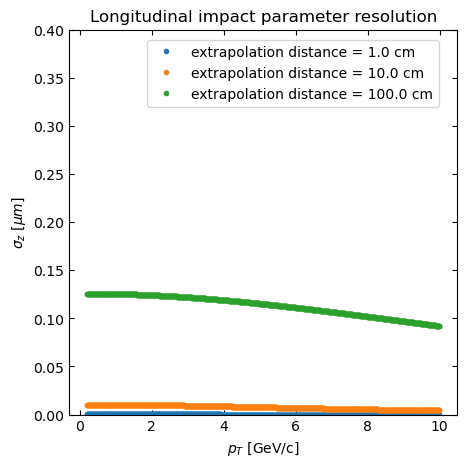

In [10]:
plt.rcParams["figure.figsize"] = (5,5)
for i, r in enumerate(extrapolation_radii):
    plt.plot(proton_momenta, scdiff[i], ".", label=f"extrapolation distance = {r*100} cm")
plt.title("Longitudinal impact parameter resolution")
plt.xlabel("$p_{T}$ [GeV/c]")
plt.ylabel("$\sigma_{z}$ [$\mu m$]")
plt.ylim(0, 0.4)
plt.tick_params(top=True, right=True, direction="in")
plt.legend(loc=(0.2, 0.8))

In [11]:
ITS2 = DetectorSetup(average_layer_radii_test, layerthickness_test, detector_resolutions_rphi_test, detector_resolutions_z_test, radiation_length_air_test, magnetic_field_strength_test)

proton_rphi_wMS = np.array([[ITS2.transverse_impact_parameter_reso(p, proton_mass, N, r, theta) for p in proton_momenta] for r in extrapolation_radii])

ITS2.MS_in_air = False

proton_rphi_woMS = np.array([[ITS2.transverse_impact_parameter_reso(p, proton_mass, N, r, theta) for p in proton_momenta] for r in extrapolation_radii])

scdiff = (proton_rphi_wMS - proton_rphi_woMS) / proton_rphi_woMS

Detector Setup initialized


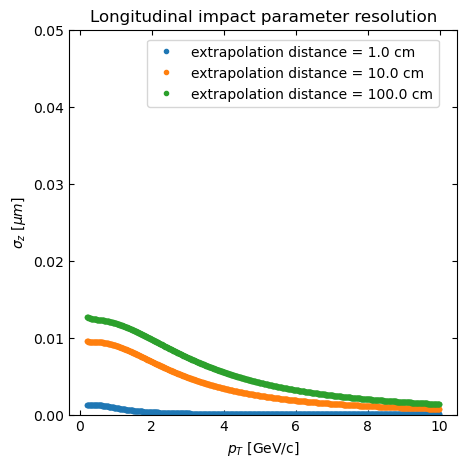

In [12]:
plt.rcParams["figure.figsize"] = (5,5)
for i, r in enumerate(extrapolation_radii):
    plt.plot(proton_momenta, scdiff[i], ".", label=f"extrapolation distance = {r*100} cm")
plt.title("Longitudinal impact parameter resolution")
plt.xlabel("$p_{T}$ [GeV/c]")
plt.ylabel("$\sigma_{z}$ [$\mu m$]")
plt.ylim(0, 0.05)
plt.tick_params(top=True, right=True, direction="in")
plt.legend(loc=(0.2, 0.8))